### A RNN model for Representational Drift Driven Through Intrinsic Exctitability and Synaptic Volatility

#### Import

In [2]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

%load_ext autoreload
%autoreload 2

from helper_functions.shared_env import *

print("Environment and libraries loaded successfully.")
print("Libraries loaded successfully.")

Environment and libraries loaded successfully.
Libraries loaded successfully.


# Setup

### Model Parameter

In [3]:
#Network parameters
N = 50 # Number of neurons

#Inhibition parameters
I0 = 5 #[5]
I1 = 1.5 #[1]
I2 = .5 #[0.05]

#Time constants
taur = 50 #firing rate decay
tauw = 1000 #synaptic weight learning rate
tautheta = 800 # threshold adaptation rate
decay = 1000 #weight decay time constant
tau_out_plus = 200 # learning time constant (higher slower learning)
tau_out_minus = 1000 # decay time constant (higher longer memory retention)

#Initial conditions
y0 = 10 
r0 = np.zeros(N) #initial firing rates
w0 = np.zeros(N * N) # initial weights
theta0 = np.zeros(N) # initial thresholds
readout_W10 = np.zeros(N)
readout_W20 = np.zeros(N)
readout_W10[:N//2] = np.random.uniform(0.01, 0.02, N//2) # initial readout weights for first readout neuron
readout_W20[N//2:] = np.random.uniform(0, 0.02, N - N//2) # initial readout weights for second readout neuron

#Simulation parameters
nstep = 13000 #Total number of time steps
dt = 1 # time step size

#Stimulus parameters
IN = 15 # input amplitude
Nstim = 10 # number of stimulation pulses per day
stim = 200 # duration of each stimulation pulse (includes the gap imediately after)
duration = 100 # duration of gap between stimulation pulses (so increasing this shortens the actual pulse duration) [default 100ms]
pause = 1000 # duration of pause before stimulation starts
delay = 3000 # delay between day starts (so the actual gap is delay - (Nstim * stim) [default 1000ms])
Nevent = 4 # number of stimulation days 

#Excitability parameters
E = 1.5 # elevated excitability factor
E_neuronN_devisions = 5 # number of neuron groups with different excitability
E_time_devisions = 4 # number of time periods with different excitability
E_sigma = 1 # std dev of excitability baseline distribution

#Volatility parameters
vol_mean = 0 # mean of volatility noise
vol_std = 0.02 # standard deviation of volatility noise

#Readout parameters
readout_theta = 0 # threshold for readout activation

#Experiment parameters
Nseed = 1 # number of different random seeds for simulations

#Save parameters in a dictionary

print("Parameters set successfully.")

Parameters set successfully.


### Input Sequence

#### Generate Input Sequence

The input array, $seq[ ]$, consists of two times for each pulse, start time and a end time.

In [4]:
#Constructing the stimulus sequence
seq = []
for ev in range(Nevent):
    for i in range(Nstim):
        seq.append(pause + i*stim + delay*ev)
        seq.append(pause + i*stim + duration + delay*ev)

def INPUT(t):
    input_vector = np.zeros(N)
    idx = np.searchsorted(seq, t)
    
    # If idx is odd, we are currently 'inside' a pulse (between a start and end step)
    if idx % 2 == 1:
        pulse_num = idx // 2
        
        # Stimulate Context A for even pulse numbers, Context B for odd
        if pulse_num % 2 == 0:
            input_vector[0:int(N/2)] = IN
        else:
            input_vector[int(N/2):N] = IN
            
    return input_vector
    
index = [range(0,N), # firing rates
         range(N,N + N*N), # synaptic weights
         range(N + N*N,N + N*N +N), #excitability
         range(N + N*N +N,N + N*N+N+N), #thresholds
         range(N + N*N+N+N,N + N*N+N+N+N), #readout 1 weights
         range(N + N*N+N+N+N,N + N*N+N+N+N+N), #readout 2 weights
         ] 

day_timesteps = []
day_timesteps.append(0)
for ev in range(Nevent):
        day_timesteps.append(int((pause + delay*ev + Nstim*stim)))
print(day_timesteps)

[0, 3000, 6000, 9000, 12000]


#### Visualise Input Sequence

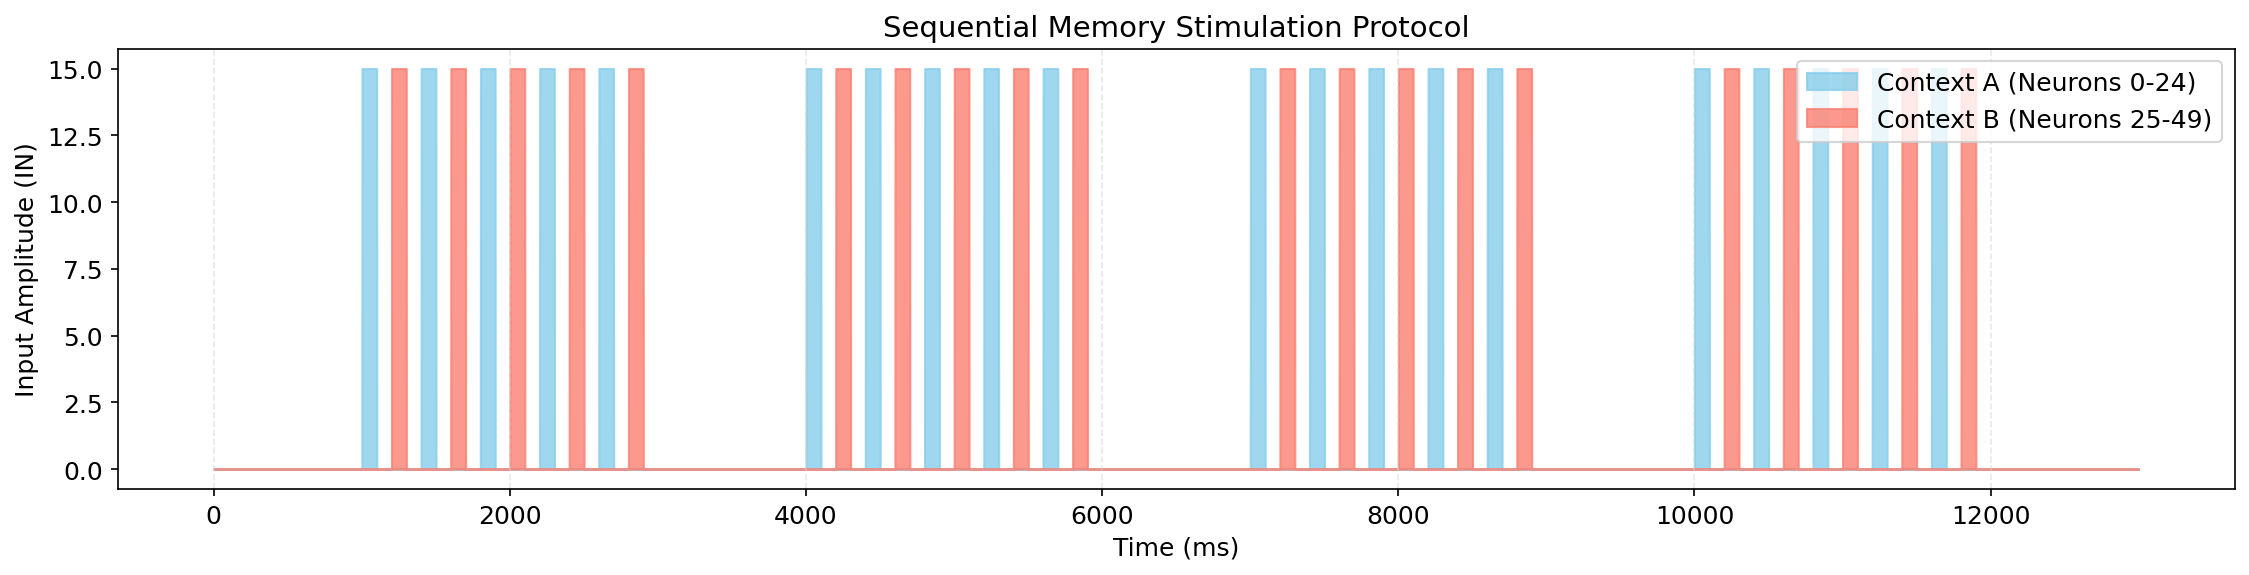

In [5]:
%matplotlib inline

#Visualising the input sequence
visualise_input_sequence(**locals())

### Excitability Fluctuations

#### Generate Excitability Function

In [6]:
exc0 = np.zeros(N)
exc0 = np.random.normal(0,E_sigma,N)
exc0 = np.sqrt(exc0*exc0)
Emat = np.zeros((N,nstep))
for i in range(E_neuronN_devisions):
    for j in range(E_time_devisions):
        if i == j+1:
            #print("N: ", i*int(N/E_neuronN_devisions), " to ", (i+1)*int(N/E_neuronN_devisions), " Time: ", j*int(nstep/E_time_devisions), " to ", (j+1)*int(nstep/E_time_devisions))
            Emat[i*int(N/E_neuronN_devisions):(i+1)*int(N/E_neuronN_devisions), j*int(nstep/E_time_devisions):(j+1)*int(nstep/E_time_devisions)] = E
Emat += np.repeat(exc0[np.newaxis], nstep,axis=0).T


#### Visualise Excitability

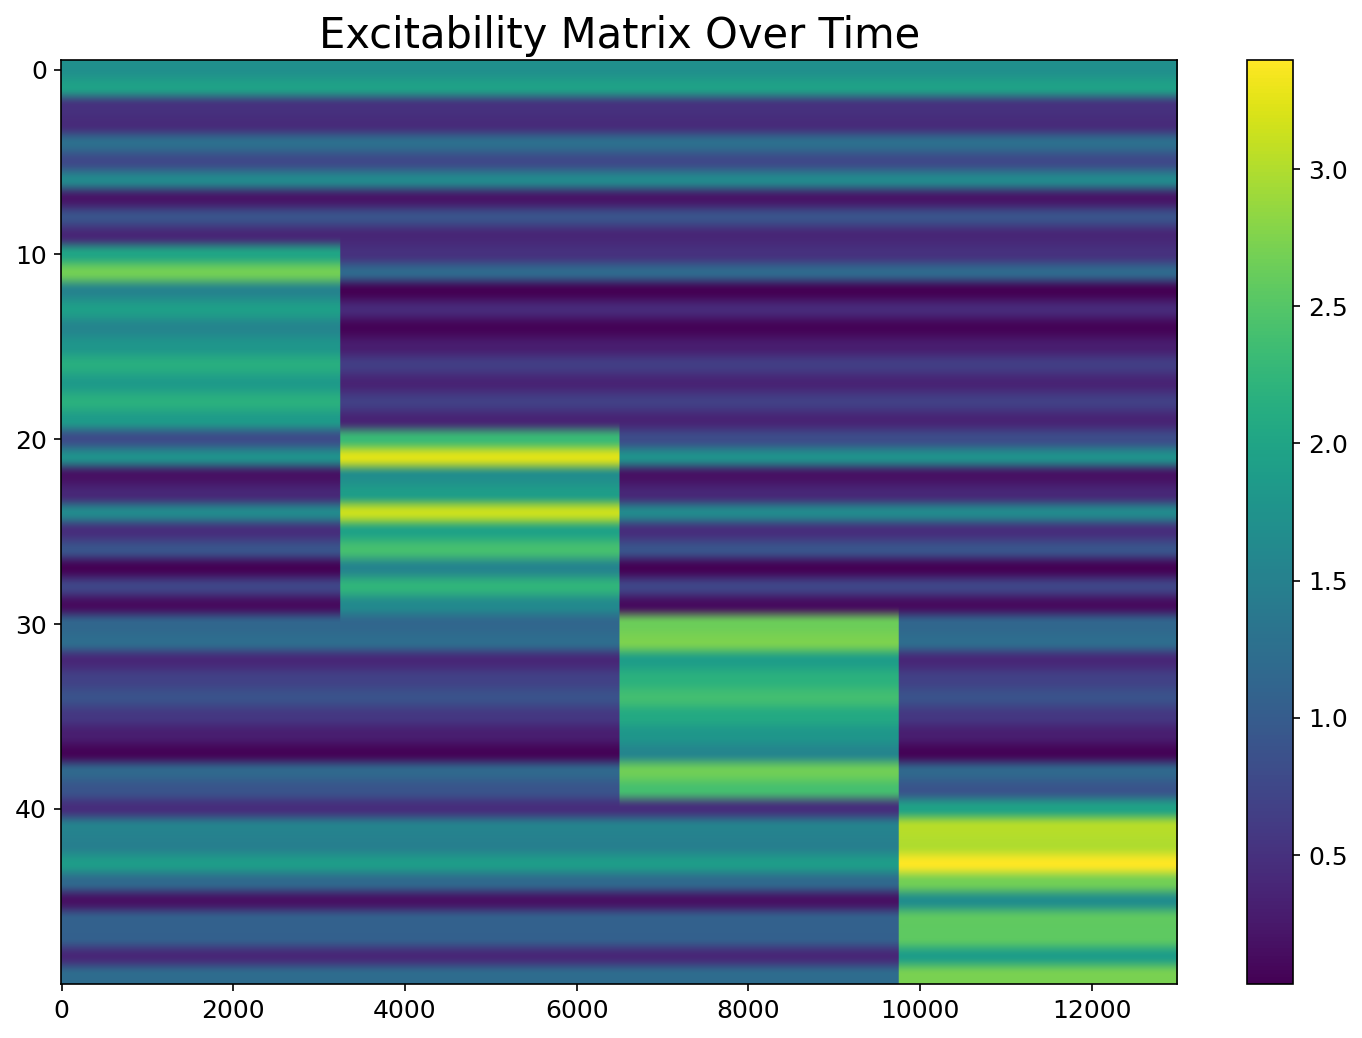

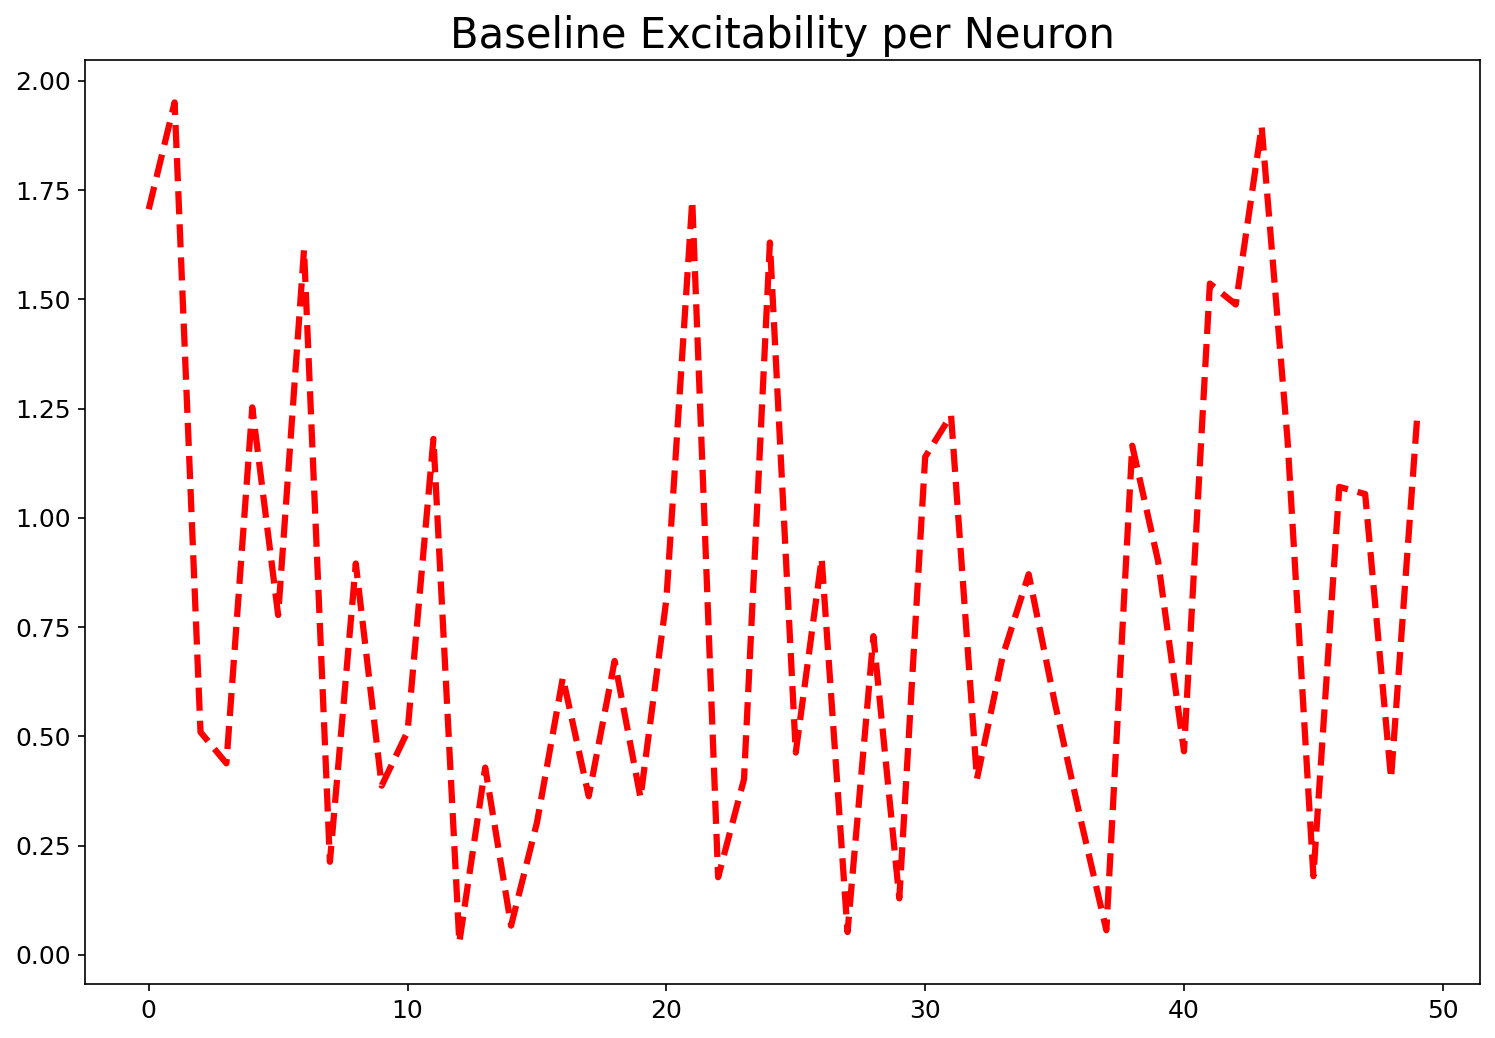

In [7]:
%matplotlib inline
visualise_excitability(**locals())

# Main Loop

### Update Function

Implement the main update function across the network.
<br>
Spike Updates <br>
Inhibition current (Eq. 1):
$$
r_{inhib} = I_0 + I_1 \cdot \sum_{i = 0}{r_i} + I_2 \cdot \sum_{i = 0}{r_i^2}
$$
Firing rate equation (Eq. 2): 
$$
\frac{dr}{dt} = (-r + \phi[w \cdot r + I_{ext}(t) - I_{inhib} + E(t)])
$$

Theta Updates <br>
Theta equation (Eq. 3):
$$
\frac{d\theta}{dt} = \frac{\frac{r}{y_0} - \theta}{\tau_\theta}
$$

Weight Updates <br>
Weight Equation (Eq. 4):
$$
\frac{dw}{dt} = \frac{ \sum{r_i \times r_j}}{\tau_w} - \frac{w}{decay} + \sigma
$$
(clamped between 1 and 0)

Excitability Updates <br>
Excitability Equation (Eq. 4):
$$
\frac{dE}{dt} = 0
$$
(follows Emat not time evolution)

In [8]:
def f(yt,t,tag,dt):
    # define values
    global theta
    r = yt[index[0]][np.newaxis].T # Index 0: firing rates
    r = r*(r>1e-5) # say its zero if its very small

    W = yt[index[1]].reshape((N,N)) # Index 1: synaptic weights

    exc = Emat[:,t][np.newaxis].T

    theta = yt[index[3]][np.newaxis].T # Index 3: thresholds

    readout_1W = yt[index[4]][np.newaxis].T # Index 4: readout weights for first readout neuron
    readout_2W = yt[index[5]][np.newaxis].T # Index 5: readout weights for second readout neuron

    #inhibition equation (Eq. 1)
    rinhib = I0 + np.sum(r)*I1 + np.sum(np.multiply(np.maximum(0,r),r))*I2

    #firing rate evolution (Eq. 2)
    drdt = (-r + np.maximum(0,W.dot(r) + INPUT(t)[np.newaxis].T - rinhib + exc ) )/taur

    #theta evolution (Eq. 3)
    dthetadt = np.zeros(N)
    dthetadt = ( r/y0 - theta ) / tautheta

    #weight evolution (Eq. 4)
    dWdt = r.dot(r.T) / tauw - W/decay + np.random.normal(vol_mean,vol_std,(N,N))
    dWdt = np.multiply(dWdt,np.logical_not(np.logical_or(np.logical_and(W>=1,dWdt>0),np.logical_and(W<=0,dWdt<0))))

    #excitation evolution
    dexcdt = np.zeros(N)
    #this is essentially dead code as it follows emat instead of a differential evolution

    # Input-gated learning: readout weights only update during their respective context input
    # This is analogous to neuromodulatory gating — plasticity is only enabled during salient events
    context_A_active = float(np.any(INPUT(t)[:N//2] > 0))
    context_B_active = float(np.any(INPUT(t)[N//2:] > 0))

    # Readout 1 learns only during Context A
    h_readout_1W = 1.0 - np.sum(readout_1W)
    readout_1r = np.dot(readout_1W.T, r)
    dreadout_1Wdt = context_A_active * ((h_readout_1W * r * readout_1r / tau_out_plus) - (readout_1W / tau_out_minus))

    # Readout 2 learns only during Context B
    h_readout_2W = 1.0 - np.sum(readout_2W)
    readout_2r = np.dot(readout_2W.T, r)
    dreadout_2Wdt = context_B_active * ((h_readout_2W * r * readout_2r / tau_out_plus) - (readout_2W / tau_out_minus))

    #reshape y
    dydt = np.concatenate((drdt.flatten(),
                           dWdt.reshape((N*N)).flatten(),
                           dexcdt.flatten(),
                           dthetadt.flatten(),
                           dreadout_1Wdt.flatten(),
                           dreadout_2Wdt.flatten()))

    return dydt

### Run Function

Update the state matrix paramters according to the Euler Method:
$$\mathbf{y}_{n+1} = \mathbf{y}_n + \Delta t \cdot f(\mathbf{y}_n, t_n, \text{tag}, \Delta t)$$

$\mathbf{y}_{n+1}$ => New state matrix at $t + 1$ <br>
$\mathbf{y}_n$ => Current state matrix at $t$ <br>
$\Delta t$ => Timescale of each system update <br>
$t_n$ => Current timestep of the model <br>
$tag$ => Currently redundant <br>


In [9]:
def run(INPUT):
    global theta
    theta = 0
    global step
    step = 0
    tag = 0
    thetaL = np.zeros((N,1))
    y0 = np.concatenate((r0,w0,exc0,theta0,readout_W10,readout_W20))
    y = np.zeros((len(y0), nstep)) #y is a complete description of the enviroment of all time
    y[:,0] = y0
    for step in range(nstep-1):
        y[:,step+1] = (y[:,step] + dt * f(y[:,step],dt*step,tag,dt)[np.newaxis]);
    return y

### Multi-Seed Experiment loop

In [10]:
vol_std = 0.02
V_list = np.zeros([4,N,Nseed]) #list of different V vectors for different seeds
for seed in tqdm(range(Nseed)):
    print("carrying out seed " + str(seed))
    
    # initialisation
    np.random.seed(seed)
    r0 = np.zeros(N)
    W0 = np.zeros(N*N)
    exc0 = np.zeros(N)
    theta0 = np.zeros(N)
    #Emat = np.zeros(nstep)

    # run
    y = run(INPUT)
    exc = y[index[2][:],:]
    r = y[index[0][:],:]
    theta = y[index[3][:],:]


  0%|          | 0/1 [00:00<?, ?it/s]

carrying out seed 0


100%|██████████| 1/1 [00:05<00:00,  5.18s/it]


# Visualisation Code

#### Transient Firing Rates (heatmap)

The graph plots the firing rates of neurons over time, showing how the activity can drift. The line $np.maximum(0,r)$ just eliminates tiny negatives resulting from floating point errors.

The individual blocks represent different days in the simulation.

The flickers within a block result from the pulse nature of the input.

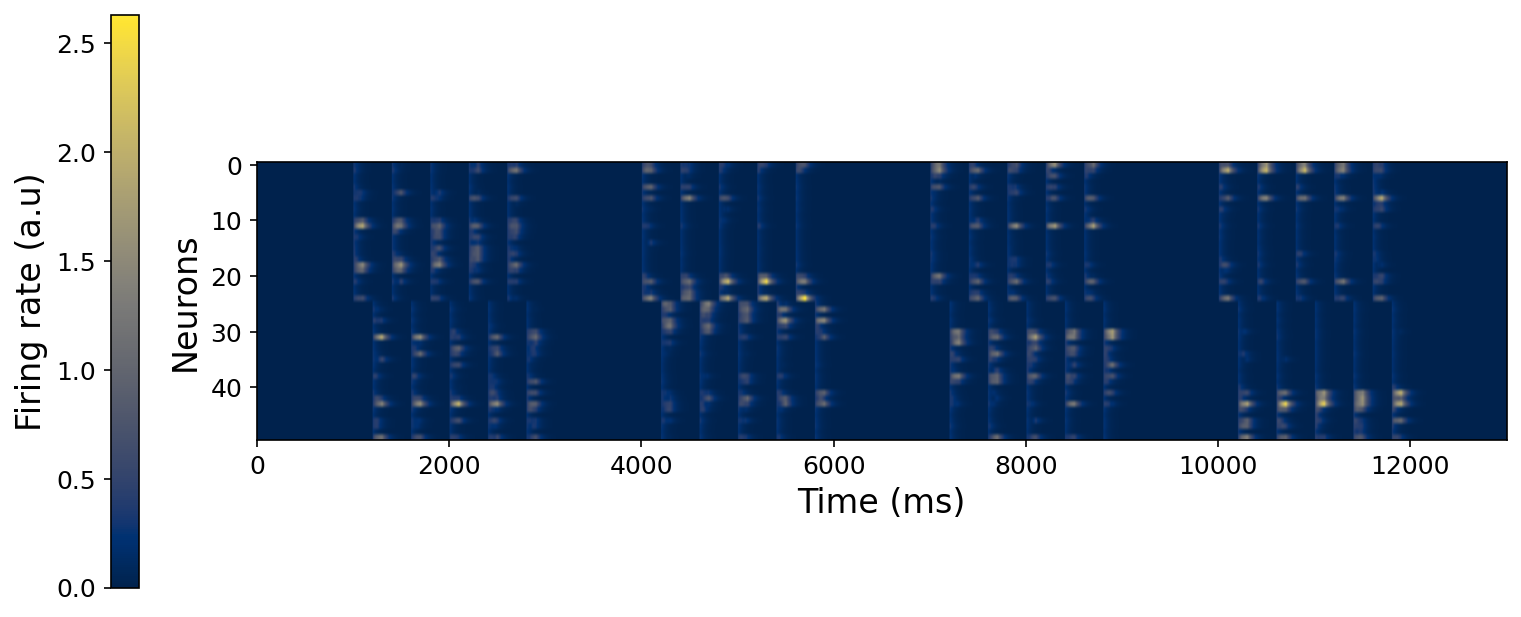

In [11]:
%matplotlib inline
visualise_firing_rates(**locals())

#### Transient Firing Rates (line graph)

This is a medium helpful graph adapted from Delamare et al. By default, the black line represent a 'spaghetti' amalgamation of all the transient firing rates across the experiment, while the red line repsents the same for just a specific selection of neurons.

This is most helpful to examine a specific neurons response in relation to the above heat map but the exact tuning of neurons that show drift likely needs to be changed for each experiment.


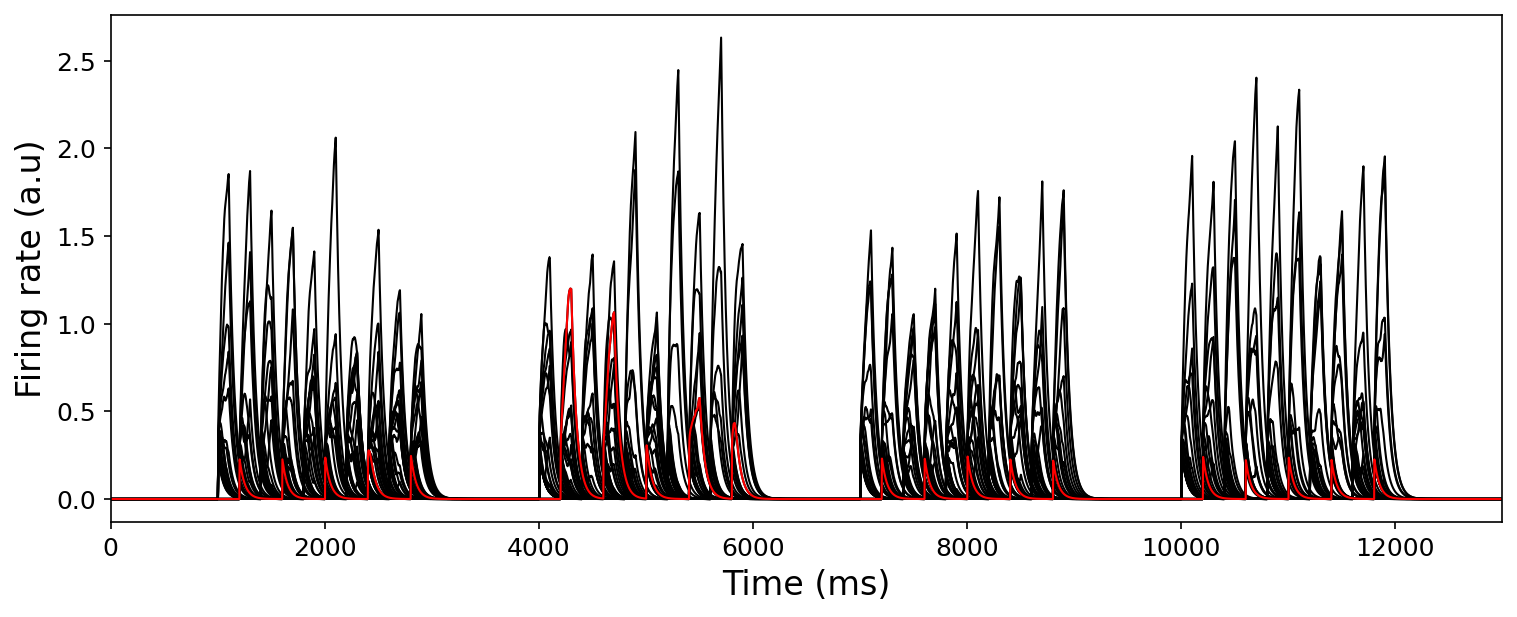

In [12]:
%matplotlib inline
visualise_transient_firing_rates(29,30,**locals())


#### Recurrent Weight Matrix

This shows the reccurrent weights of the network at the end of each day. You should be able to observe a nice drift in the location.

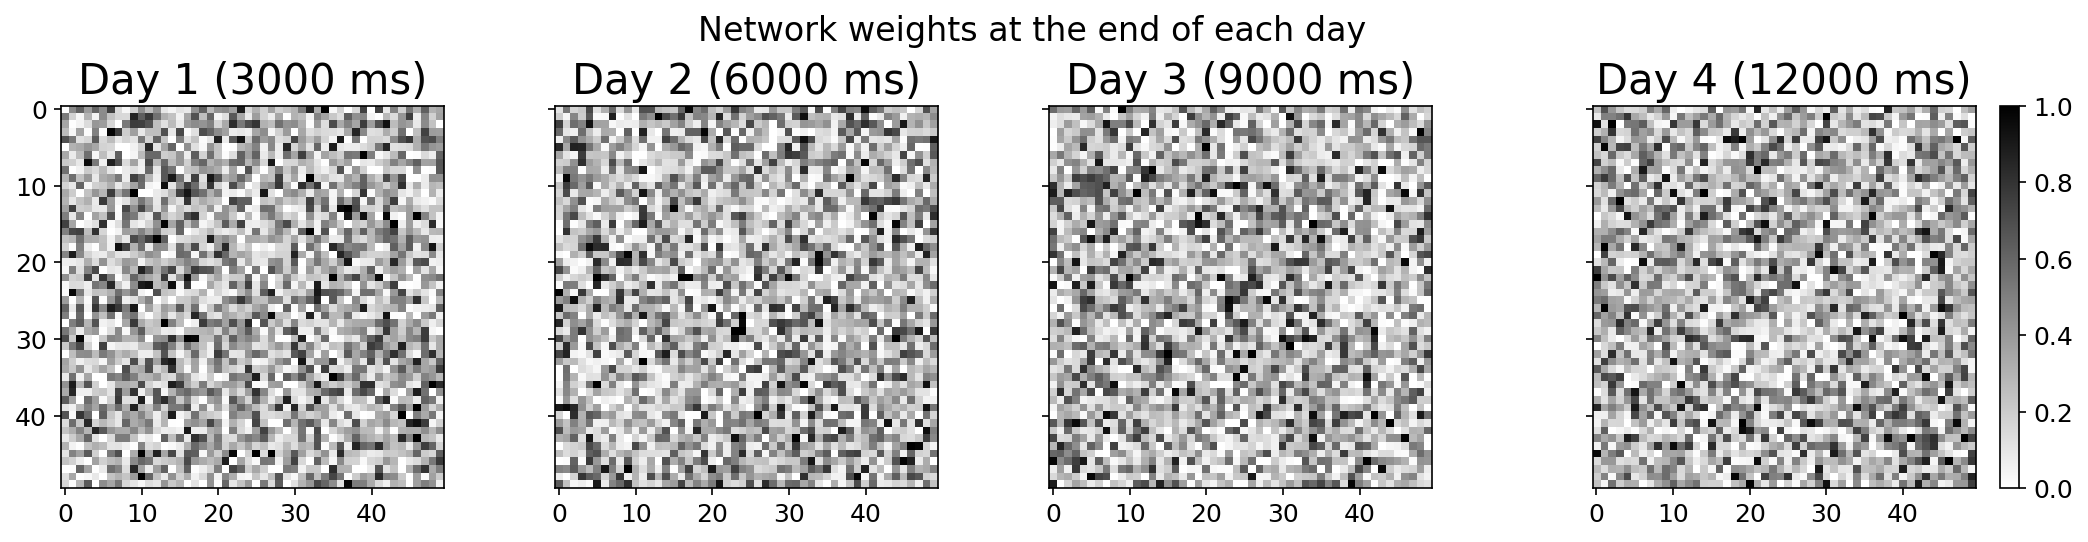

In [13]:
%matplotlib inline
visualise_weight_matrix(**locals())

#### Interactive Visualiser

This is a interactive tool that shows how all aspects of the model evolve with time. It's a bit laggy, at least on my laptop, but helps give a intuiton for the mechanism and hopefully will make understanding future parameter perturbations easier.

In [14]:
dynamic_visualiser(**locals())
tworeadout_visualiser(**locals())
pass

IntSlider(value=0, description='Time (ms):', layout=Layout(width='800px'), max=12999, step=100)

Output()

4
13000
[0, 3000, 6000, 9000, 12000]


array([-0.30024858,  0.155831  , -0.28013751, ..., -0.54639196,
        0.12665115, -0.31101781], shape=(1200,))

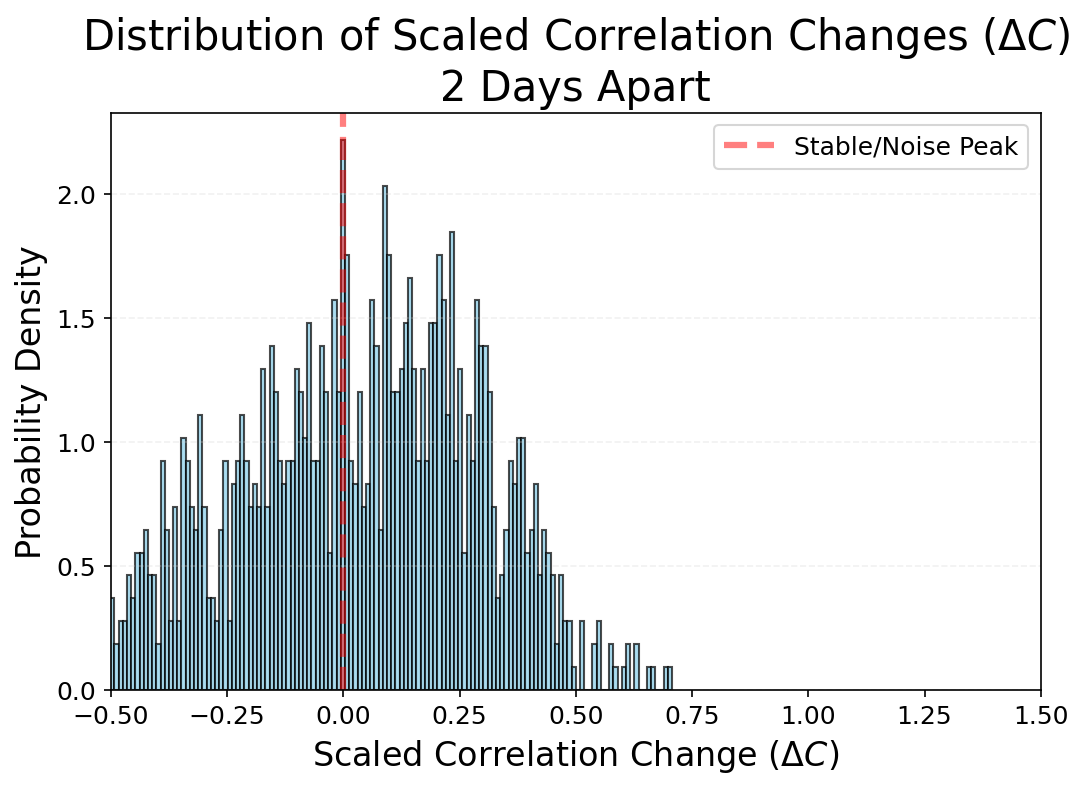

In [15]:
print(Nevent)
print(nstep)
print(day_timesteps)
visualise_correlation_change_over_day(2,0.05,**locals())


# Parameter Perturbation
Sweep over `E_sigma` (excitability baseline std) and `vol_std` (synaptic volatility std) to measure readout selectivity stability.

**Selectivity** for readout $k$ is defined as:

$$S_k = \frac{1}{|T_k|}\sum_{t \in T_k} y_k(t) - \frac{1}{|T_{\neg k}|}\sum_{t \in T_{\neg k}} y_k(t)$$

where $y_k(t) = \mathbf{w}_k^\top \mathbf{r}(t)$ is the readout output and $T_k$ is the set of timesteps when context $k$ is active. A positive value means the readout fires more for its correct context than the wrong one.

In [16]:
# --- Parameter Perturbation Sweep ---
E_baseline_values = [0.5, 1.0, 1.5, 2.0]
vol_std_values     = [0.005, 0.01, 0.02, 0.04]
n_seeds            = 5  # number of seeds to average over

stability_grid     = np.zeros((len(E_baseline_values), len(vol_std_values)))
selectivity_1_grid = np.zeros((len(E_baseline_values), len(vol_std_values)))
selectivity_2_grid = np.zeros((len(E_baseline_values), len(vol_std_values)))

# Timestep masks for the last day (fixed — independent of parameters)
last_day_start = day_timesteps[-2]
last_day_end   = day_timesteps[-1]
t_range = np.arange(last_day_start, last_day_end)
mask_A = np.array([np.any(INPUT(t)[:N//2] > 0) for t in t_range])
mask_B = np.array([np.any(INPUT(t)[N//2:] > 0) for t in t_range])

for i, E_baseline_sweep in enumerate(tqdm(E_baseline_values, desc='E_baseline')):
    for j, vol_std_sweep in enumerate(vol_std_values):

        vol_std = vol_std_sweep
        sel_1_seeds = []
        sel_2_seeds = []

        for seed in range(n_seeds):

            # Rebuild excitability matrix
            np.random.seed(seed)
            exc0 = np.random.normal(0, E_sigma, N)
            exc0 = np.sqrt(exc0 * exc0)
            Emat = np.zeros((N, nstep))
            for ii in range(E_neuronN_devisions):
                for jj in range(E_time_devisions):
                    if ii == jj + 1:
                        Emat[ii*int(N/E_neuronN_devisions):(ii+1)*int(N/E_neuronN_devisions),
                             jj*int(nstep/E_time_devisions):(jj+1)*int(nstep/E_time_devisions)] = E_baseline_sweep
            Emat += np.repeat(exc0[np.newaxis], nstep, axis=0).T

            # Reset initial conditions
            np.random.seed(seed)
            r0          = np.zeros(N)
            w0          = np.zeros(N * N)
            theta0      = np.zeros(N)
            readout_W10 = np.zeros(N)
            readout_W20 = np.zeros(N)
            readout_W10[:N//2] = np.random.uniform(0.01, 0.02, N//2)
            readout_W20[N//2:] = np.random.uniform(0.01, 0.02, N - N//2)

            # Run simulation
            y_p = run(INPUT)

            # Compute readout outputs over last day: y_k(t) = w_k . r(t)
            r_last  = y_p[index[0], last_day_start:last_day_end]
            w1_last = y_p[index[4], last_day_start:last_day_end]
            w2_last = y_p[index[5], last_day_start:last_day_end]
            y1_last = np.sum(w1_last * r_last, axis=0)
            y2_last = np.sum(w2_last * r_last, axis=0)

            # Selectivity: mean output during correct context - mean during wrong context
            sel_1 = np.mean(y1_last[mask_A]) - np.mean(y1_last[mask_B]) if mask_A.any() and mask_B.any() else 0
            sel_2 = np.mean(y2_last[mask_B]) - np.mean(y2_last[mask_A]) if mask_A.any() and mask_B.any() else 0
            sel_1_seeds.append(sel_1)
            sel_2_seeds.append(sel_2)

        # Average across seeds
        s1 = np.mean(sel_1_seeds)
        s2 = np.mean(sel_2_seeds)
        selectivity_1_grid[i, j] = s1
        selectivity_2_grid[i, j] = s2
        stability_grid[i, j]     = (s1 + s2) / 2

print("Sweep complete.")
print(stability_grid)

E_baseline: 100%|██████████| 4/4 [06:45<00:00, 101.26s/it]

Sweep complete.
[[0.41241331 0.39718453 0.37607907 0.36580239]
 [0.38123213 0.37084991 0.35903841 0.35463234]
 [0.34631685 0.34116968 0.33927315 0.34045462]
 [0.32500843 0.32314652 0.32412184 0.32899888]]


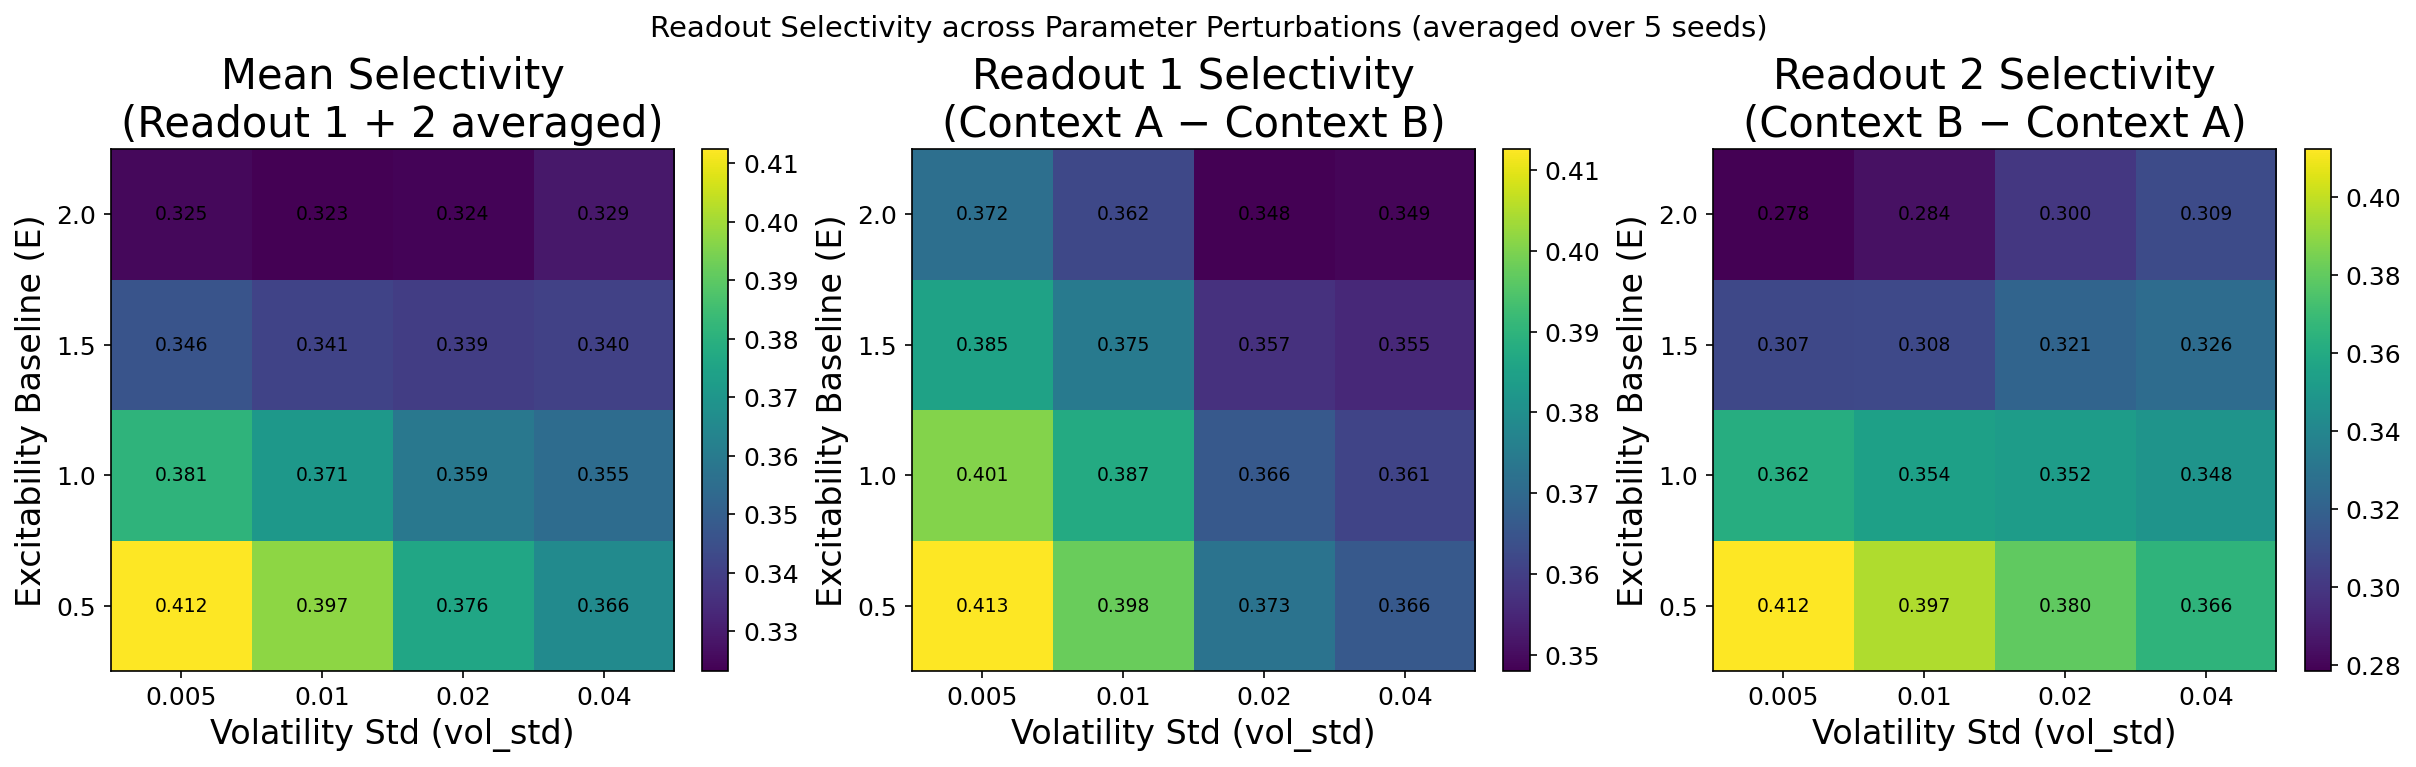

In [18]:
%matplotlib inline
fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
fig.suptitle(f'Readout Selectivity across Parameter Perturbations (averaged over {n_seeds} seeds)', fontsize=14)

datasets = [
    (stability_grid,     'Mean Selectivity\n(Readout 1 + 2 averaged)'),
    (selectivity_1_grid, 'Readout 1 Selectivity\n(Context A \u2212 Context B)'),
    (selectivity_2_grid, 'Readout 2 Selectivity\n(Context B \u2212 Context A)'),
]

for ax, (data, title) in zip(axes, datasets):
    im = ax.imshow(data, aspect='auto', origin='lower',
                   extent=[0, len(vol_std_values), 0, len(E_baseline_values)])
    ax.set_xticks(np.arange(len(vol_std_values)) + 0.5)
    ax.set_xticklabels(vol_std_values)
    ax.set_yticks(np.arange(len(E_baseline_values)) + 0.5)
    ax.set_yticklabels(E_baseline_values)
    ax.set_xlabel('Volatility Std (vol_std)')
    ax.set_ylabel('Excitability Baseline (E)')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    for row in range(len(E_baseline_values)):
        for col in range(len(vol_std_values)):
            ax.text(col + 0.5, row + 0.5, f'{data[row, col]:.3f}',
                    ha='center', va='center', fontsize=9, color='black')

plt.show()

# Population Trajectory Analysis (PCA)

Fit PCA on **day 1 only** to define a fixed 3D coordinate system, then project all days through the same transform. This lets us see how the population geometry drifts across days while keeping the axes comparable.

- **Blue** = Context A active, **Red** = Context B active, **Grey** = between pulses
- Each day is plotted as a separate panel
- Drift = trajectories move across days; separation = A and B stay in distinct regions

Day 1 variance explained: [0.491 0.264 0.07 ]


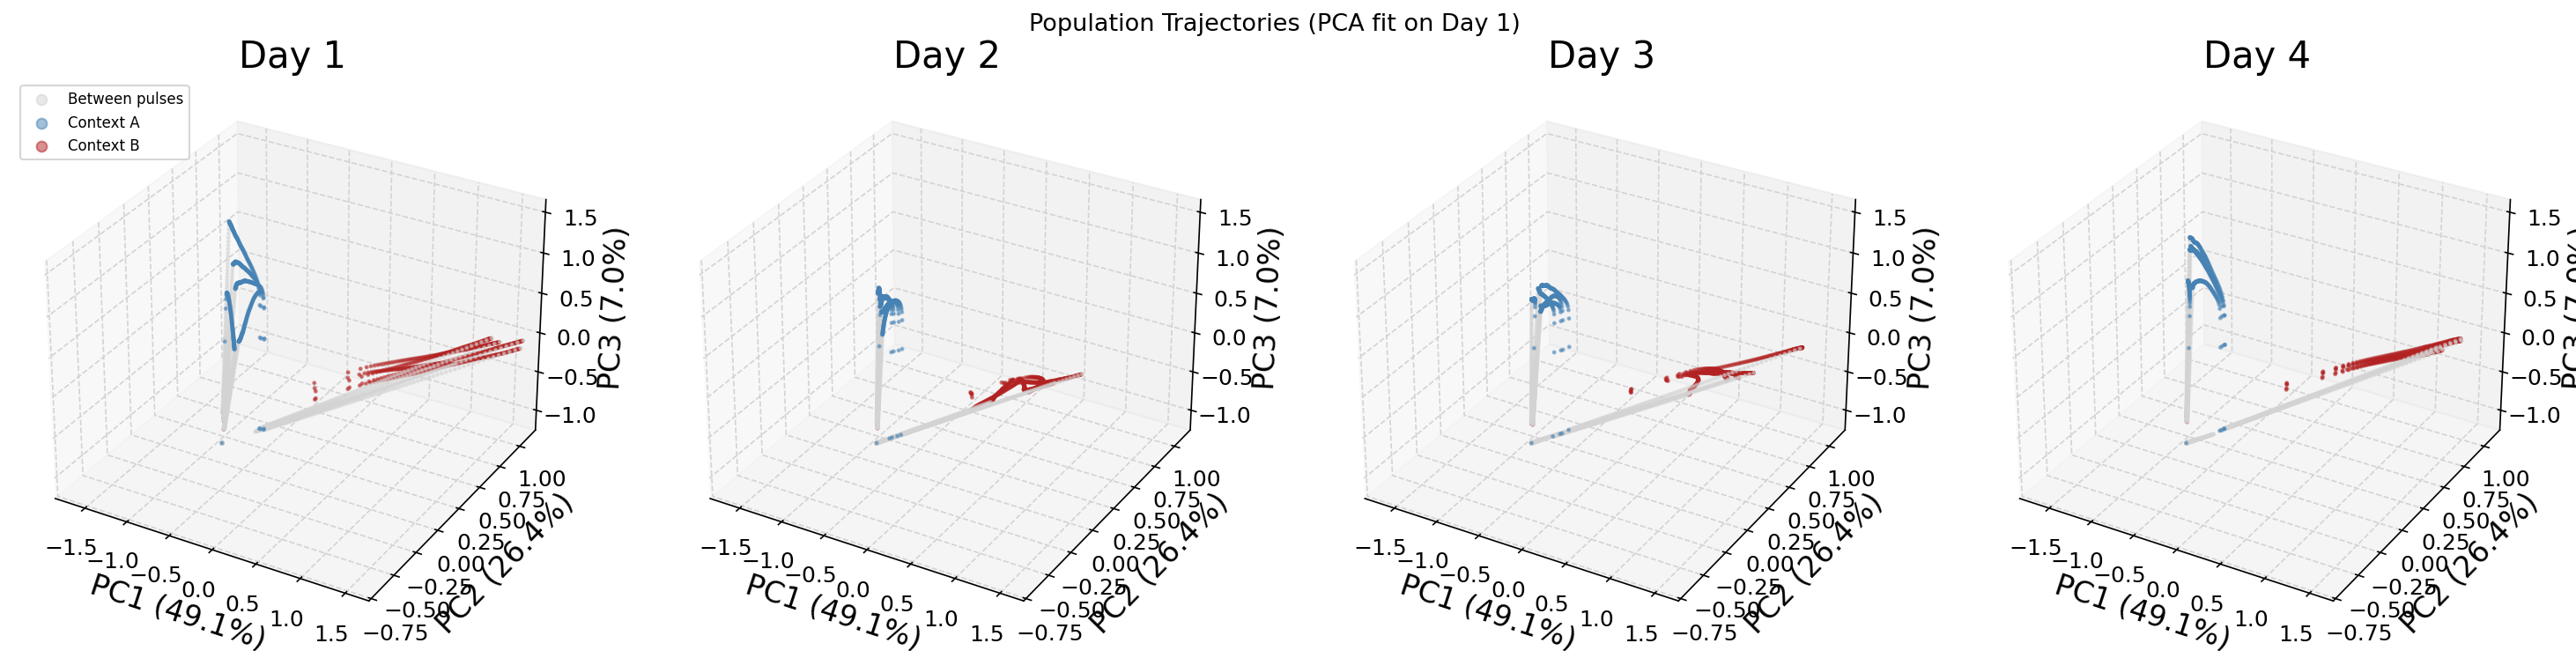

In [28]:
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# --- Extract firing rates per day ---
r_all = y[index[0], :]  # shape: (N, nstep)

# Build per-day firing rate matrices and context labels
day_data   = []
day_labels = []

for d in range(len(day_timesteps) - 1):
    t_start = day_timesteps[d]
    t_end   = day_timesteps[d + 1]
    r_day   = r_all[:, t_start:t_end]

    labels = np.zeros(t_end - t_start, dtype=int)
    for t_idx, t in enumerate(range(t_start, t_end)):
        inp = INPUT(t)
        if np.any(inp[:N//2] > 0):
            labels[t_idx] = 1  # Context A
        elif np.any(inp[N//2:] > 0):
            labels[t_idx] = 2  # Context B

    day_data.append(r_day)
    day_labels.append(labels)

# --- Fit PCA on day 1 only ---
pca = PCA(n_components=3)
pca.fit(day_data[0].T)
print(f"Day 1 variance explained: {pca.explained_variance_ratio_.round(3)}")

# --- Project all days through the same PCA ---
day_pca = [pca.transform(r_day.T) for r_day in day_data]

# --- Compute global axis limits across all days ---
all_pts = np.concatenate(day_pca, axis=0)
pad = 0.1
x_lim = (all_pts[:, 0].min() - pad, all_pts[:, 0].max() + pad)
y_lim = (all_pts[:, 1].min() - pad, all_pts[:, 1].max() + pad)
z_lim = (all_pts[:, 2].min() - pad, all_pts[:, 2].max() + pad)

# --- Plot ---
n_days = len(day_data)
fig = plt.figure(figsize=(5 * n_days, 5))
colors = {0: 'lightgrey', 1: 'steelblue', 2: 'firebrick'}
labels_legend = {0: 'Between pulses', 1: 'Context A', 2: 'Context B'}

for d in range(n_days):
    ax = fig.add_subplot(1, n_days, d + 1, projection='3d')
    proj   = day_pca[d]
    labels = day_labels[d]

    for ctx in [0, 1, 2]:
        mask = labels == ctx
        if mask.any():
            ax.scatter(proj[mask, 0], proj[mask, 1], proj[mask, 2],
                       c=colors[ctx], label=labels_legend[ctx],
                       s=2, alpha=0.5)

    ax.set_xlim(x_lim)
    ax.set_ylim(y_lim)
    ax.set_zlim(z_lim)

    ax.set_title(f'Day {d + 1}')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)')
    if d == 0:
        ax.legend(markerscale=4, loc='upper left', fontsize=8)

plt.suptitle('Population Trajectories (PCA fit on Day 1)', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.spatial import ConvexHull

# --- 3D trajectory plot: one context, all days as coloured lines ---
# Each pulse is plotted as a continuous curve rather than scattered dots.
# This shows the network's state trajectory during each activation — the
# shape of the curve reflects the dynamics, the position reflects the representation.

ctx_to_plot = 1          # 1 = Context A, 2 = Context B
ctx_label   = 'Context A' if ctx_to_plot == 1 else 'Context B'
day_colors  = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']  # blue, green, orange, pink

fig = plt.figure(figsize=(9, 7))
ax  = fig.add_subplot(111, projection='3d')

for d in range(n_days):
    labels = day_labels[d]
    proj   = day_pca[d]       # (T_day, 3)
    color  = day_colors[d]

    # Split into individual pulses — each contiguous run of ctx_to_plot labels
    in_pulse   = False
    pulse_start = 0
    first_pulse = True

    for t in range(len(labels)):
        if labels[t] == ctx_to_plot and not in_pulse:
            in_pulse    = True
            pulse_start = t
        elif labels[t] != ctx_to_plot and in_pulse:
            in_pulse = False
            seg = proj[pulse_start:t]  # one pulse segment
            # Only add label on first pulse of each day to avoid legend clutter
            lbl = f'Day {d+1}' if first_pulse else None
            ax.plot(seg[:, 0], seg[:, 1], seg[:, 2],
                    color=color, linewidth=1.5, alpha=0.8, label=lbl)
            first_pulse = False

    # Catch pulse that runs to end of day
    if in_pulse:
        seg = proj[pulse_start:]
        lbl = f'Day {d+1}' if first_pulse else None
        ax.plot(seg[:, 0], seg[:, 1], seg[:, 2],
                color=color, linewidth=1.5, alpha=0.8, label=lbl)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)')
ax.set_title(f'{ctx_label} — Population Trajectory Drift Across Days\n'
             f'(each curve = one pulse, PCA fit on Day 1)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()